In [16]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

results = pd.read_csv("../eval/f107_test_f107_mse_subset_0064.csv")
results.columns

Index(['Unnamed: 0', 'date', 'target', 'prediction_raw', 'error'], dtype='object')

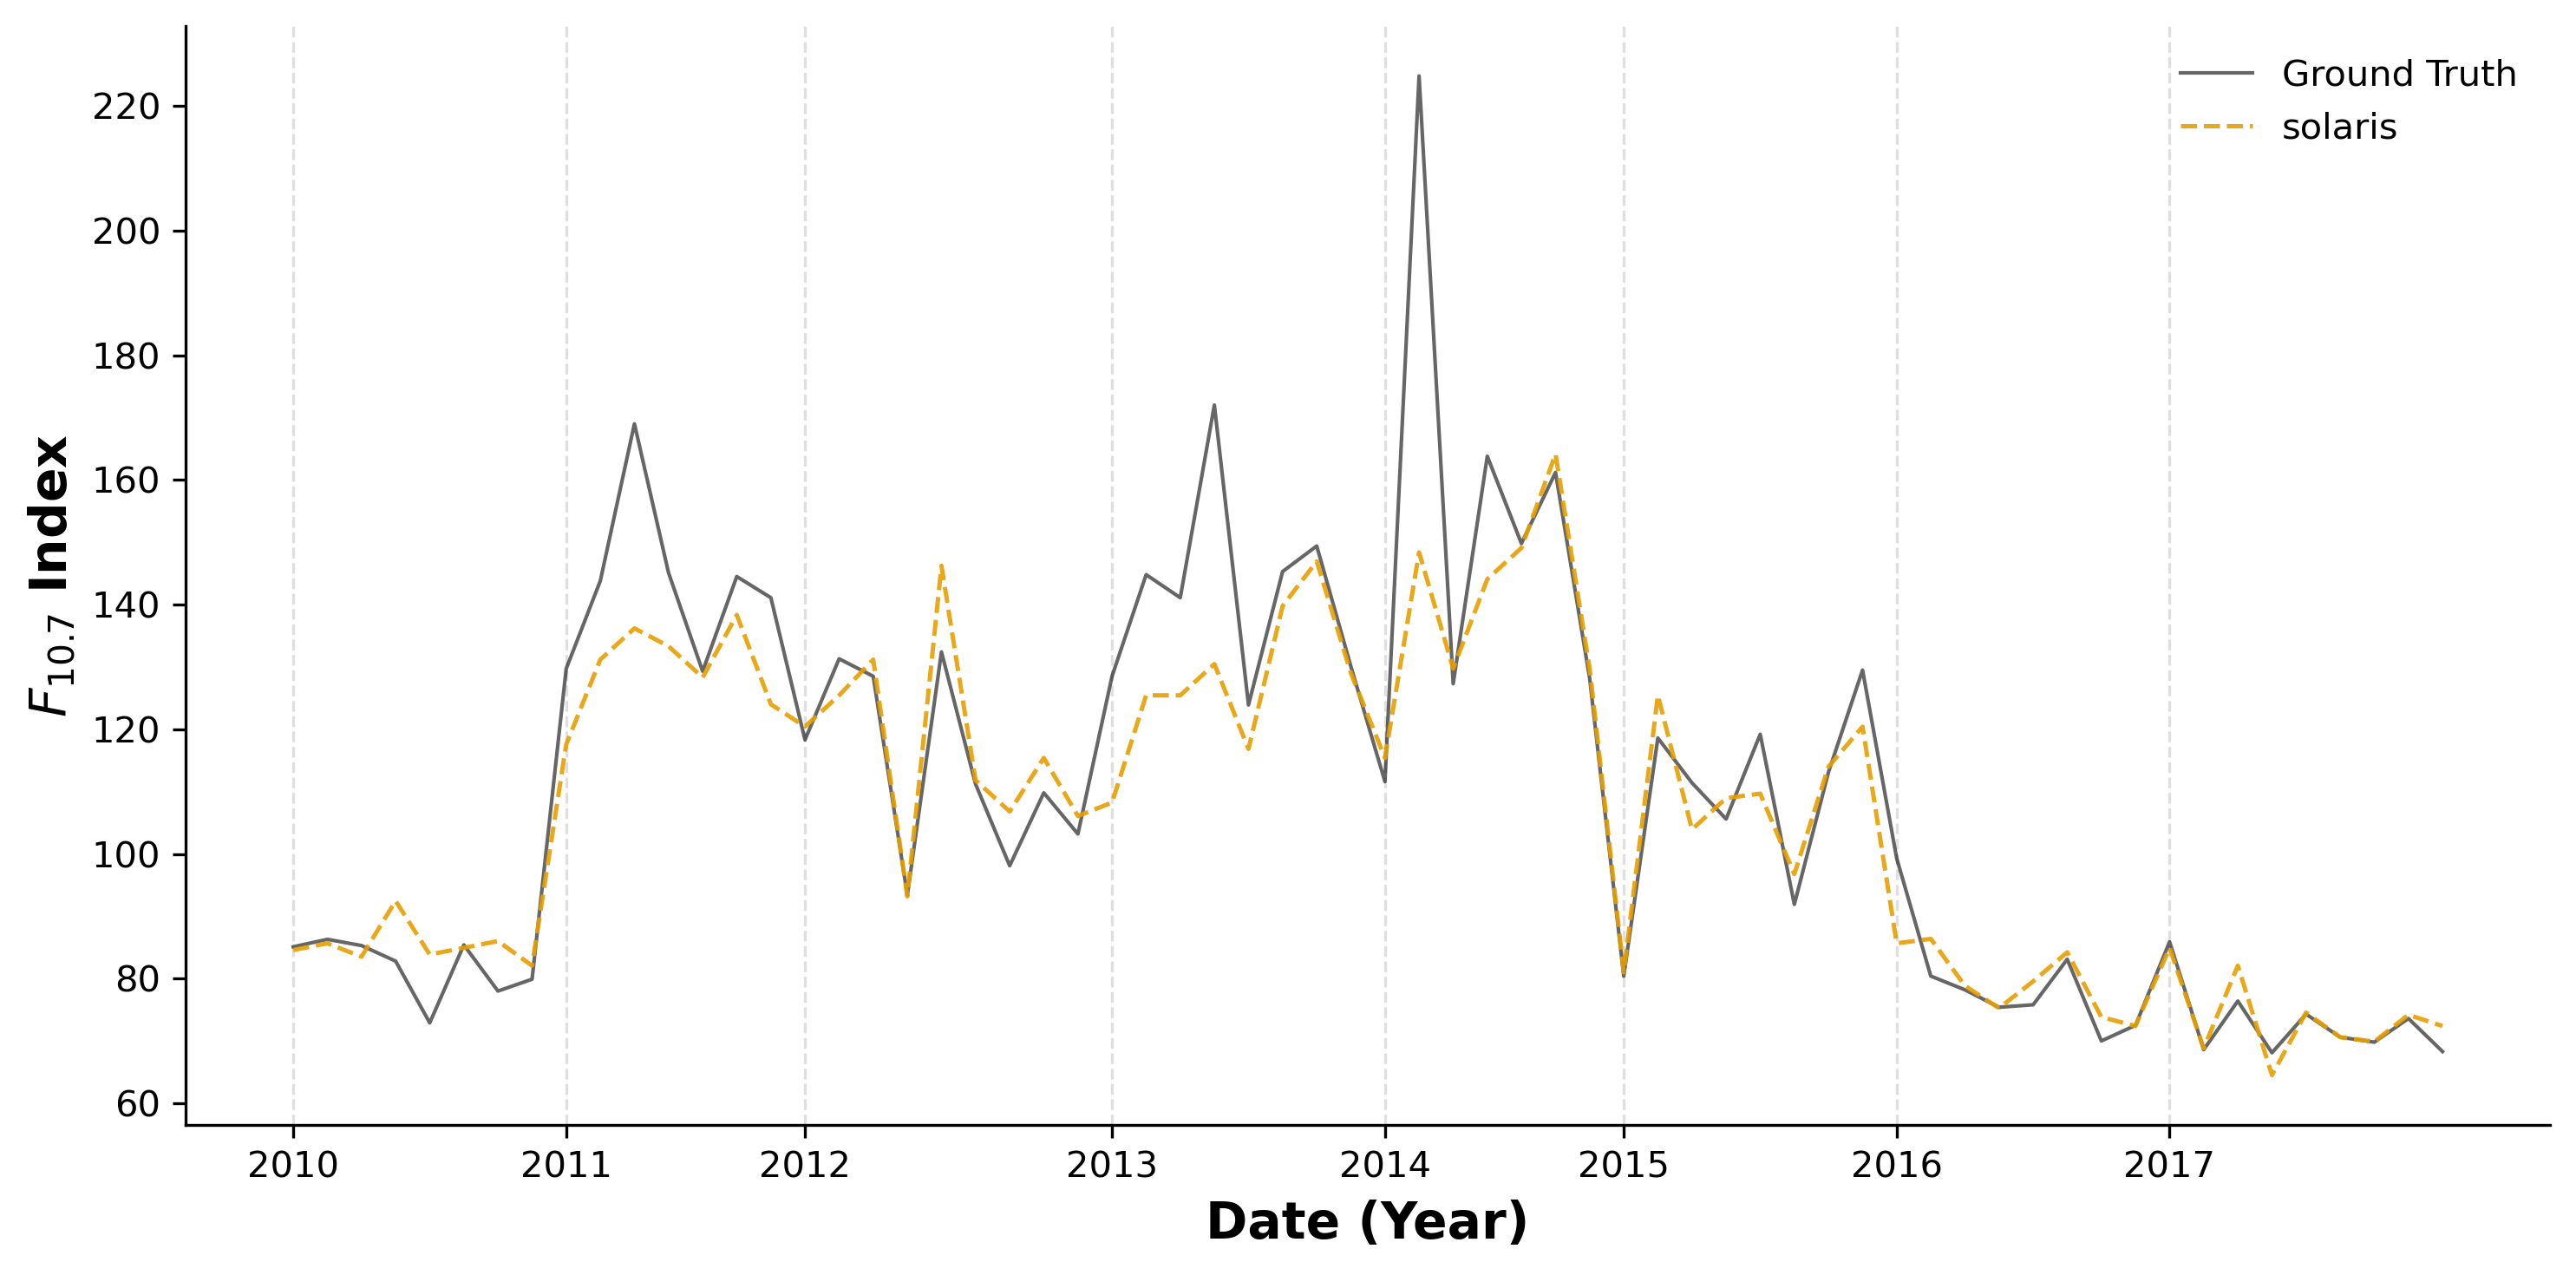

In [26]:
dates = results["date"]
years = pd.to_datetime(dates).dt.year

y = results["target"]
preds = results["prediction_raw"]

x_idx = np.arange(len(dates))
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth: Dark grey or Black is better for the "anchor" data
ax.plot(x_idx, y, label="Ground Truth", color='black', linewidth=1, alpha=0.6)

# Model 1: Orange (Okabe-Ito)
ax.plot(x_idx, preds, label="solaris", color='#E69F00', 
        linewidth=1.2, alpha=0.9, linestyle='--')

unique_years, indices = np.unique(years, return_index=True)

ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel("$F_{10.7}$ Index", fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

